---

<h1 style="text-align: center;"><strong>Data Science & Statistical Computing</strong></h1>
<h2 style="text-align: center;"><strong>Aula 01 - Conceitos Elementares</strong></h2>
<h3 style="text-align: center;"><strong>Prof. Jones Egydio</strong></h3>
<h4 style="text-align: center;"><strong>FIAP - 2026</strong></h4>
<br>
<br>



---

# **Aula 1: Data Science e IA + Ferramentas na prática**

## **Objetivos**
- Entender os conceitos básicos de Data Science e IA;
- Praticar algumas ferramentas: **Jupyter, python, numpy, pandas, matplotlib**

---
## **1. Data Science e Inteligência Artificial**

### **1.1 O papel do cientista de dados**

**Definição:** profissional que transforma dados em decisões. 

Normalmente atua em: 

- (1) entender o problema;
- (2) coletar/limpar dados;
- (3) explorar padrões;
- (4) criar análises/modelos;
- (5) comunicar resultados e medir impacto.


In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris(as_frame=True)
df = iris.frame  # já vem com as features + target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


* **Fonte:** https://archive.ics.uci.edu/dataset/53/iris

### **1.2 A relação entre Data Science e Inteligência Artificial**

**Definição:** Data Science é o conjunto de análises orientadas por dados (estatística + programação + negócio). 

IA é um conjunto que cria sistemas capazes de “executar tarefas inteligentes”, muitas vezes com modelos de machine learning.

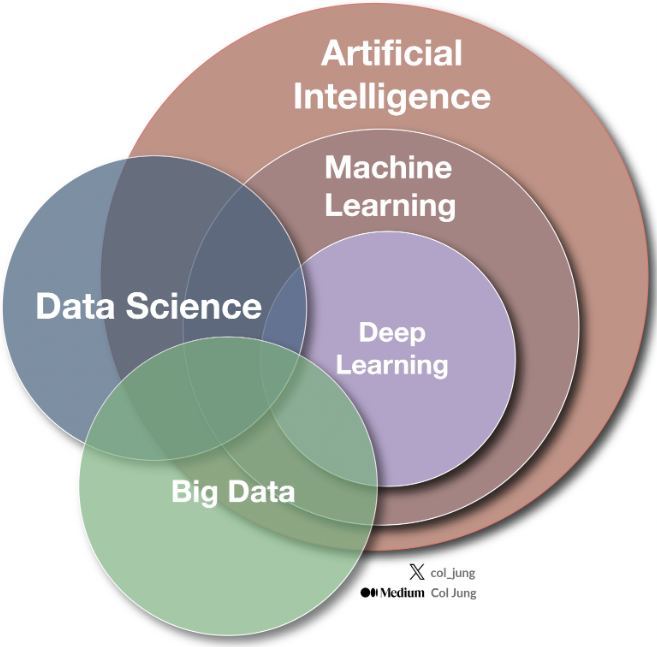

accuracy: 0.9473684210526315


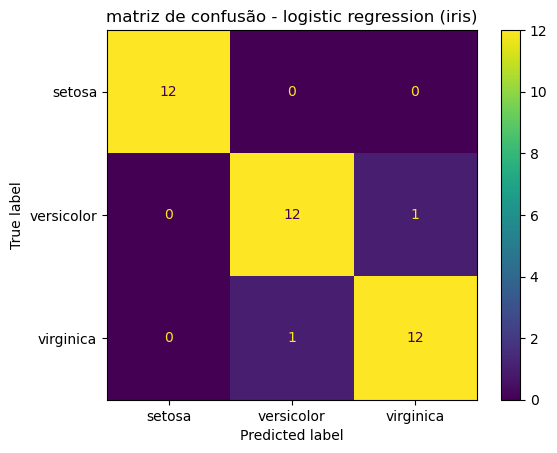

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

# 1) carregar o dataset iris em um DataFrame (df)
iris = load_iris(as_frame=True)
df = iris.frame  # features + coluna "target"

# 2) separar X e y
X = df.drop(columns=["target"])
y = df["target"]

# 3) split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 4) treinar o modelo
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

# 5) predição e métrica
pred = clf.predict(X_test)
acc = accuracy_score(y_test, pred)
print("accuracy:", acc)

# 6) gráfico: matriz de confusão
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot()
plt.title("matriz de confusão - logistic regression (iris)")
plt.show()

### **1.3 Carreiras em Data Science e IA**
**Áreas comuns:**

- Analista de dados (dashboards, métricas)
- Cientista de dados (experimentos, modelagem)
- Engenheiro de dados (pipelines, dados em produção)
- ML Engineer (treino + deploy)
- Analytics Engineer (modelagem de dados + camadas analíticas)
- Product/AI Analyst (decisões de produto)

### **1.4 Por que programadores têm que aprender data science?**

Os produtos modernos são guiados por dados (telemetria, recomendação, busca, detecção de fraude, personalização). Entender dados ajuda a projetar sistemas melhores, medir impacto e evitar conclusões erradas.

**Na prática:** um programador precisa ler dados, filtrar, agregar e visualizar rapidamente.

In [3]:
import numpy as np

# correlação com o target (apenas para ter uma sensibilidade inicial; target aqui é numérico por classe)
corr = df.corr(numeric_only=True)["target"].sort_values(ascending=False)
corr

target               1.000000
petal width (cm)     0.956547
petal length (cm)    0.949035
sepal length (cm)    0.782561
sepal width (cm)    -0.426658
Name: target, dtype: float64

In [4]:
# exemplo de agregação e checagem rápida: média por classe (target)
df.groupby("target").mean(numeric_only=True)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
target,,,,
0,5.006,3.428,1.462,0.246
1,5.936,2.770,4.260,1.326
2,6.588,2.974,5.552,2.026


### **1.5 Vantagens para quem está migrando de carreira**


Quem migra normalmente ganha vantagem ao combinar conhecimento anterior (negócio/engenharia/saúde etc.) com análise de dados. Isso melhora definição de problema, interpretação e comunicação.

**Na prática:** comunicar um insight em uma frase + gráfico.

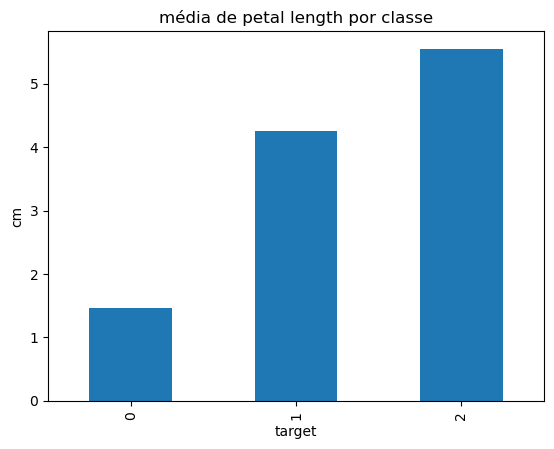

In [5]:
import matplotlib.pyplot as plt

means = df.groupby("target").mean(numeric_only=True)["petal length (cm)"]
means.plot(kind="bar")
plt.title("média de petal length por classe")
plt.ylabel("cm")
plt.show()

---
## **2. Ferramentas Essenciais**

### **2.1 Primeiros passos no Google Colab e Jupyter**

**Colab** é um ambiente de notebook no navegador. Você consegue executar python na nuvem, instalar libs com `pip`, usar gpu (quando disponível) e salvar arquivos no drive.

**Jupyter** é um ambiente similar ao **Colab**. Em geral, está presente em aplicações profissionais e acadêmicas.

In [6]:
import sys, platform
print("python:", sys.version.split()[0])
print("plataforma:", platform.platform())

python: 3.12.11
plataforma: macOS-26.2-arm64-arm-64bit


### **2.2 por que python é a linguagem preferida em data science**

Python tem sintaxe simples, ecossistema enorme (numpy/pandas/sklearn/matplotlib), comunidade forte e integração com produção.

In [7]:
import numpy as np
import time

arr = np.random.rand(2_000_000)

# loop manual
t0 = time.time()
s = 0.0
for v in arr:
    s += v
t1 = time.time()

# vetorizado
t2 = time.time()
s2 = arr.sum()
t3 = time.time()

print("loop:", round(t1-t0, 4), "s | soma:", round(s, 3))
print("numpy:", round(t3-t2, 4), "s | soma:", round(float(s2), 3))

loop: 0.1476 s | soma: 999766.977
numpy: 0.0004 s | soma: 999766.977


### **2.3 pandas e matplotlib: o kit essencial**

**Definição:**
- **pandas**: estrutura `DataFrame` para dados tabulares (colunas/linhas)
- **matplotlib**: base para gráficos em python
- **numpy**: base numérica (arrays)

A seguir, vamos conectar cada conceito com um exemplo.

#### **2.3.1 Pandas vs polars: qual usar?**

**definição:**
- **pandas** é o padrão do mercado e muito integrado com o ecossistema.
- **polars** costuma ser mais rápido em operações grandes e usa execução mais eficiente.


In [8]:
# tarefa: filtrar, criar coluna, agregar

import pandas as pd

df2 = df.copy()
df2["petal_area"] = df2["petal length (cm)"] * df2["petal width (cm)"]

res_pandas = (
    df2[df2["sepal length (cm)"] > 5.5]
    .groupby("target")["petal_area"]
    .mean()
    .sort_values(ascending=False)
)

res_pandas

target
2    11.370612
1     6.073077
0     0.450000
Name: petal_area, dtype: float64

#### **2.3.2 Falando de pandas**
**Pandas** trabalha com:
- leitura/escrita (csv, parquet, excel)
- inspeção (`head`, `info`)
- limpeza (nulos, tipos)
- transformação (filtros, joins, groupby)
- estatística descritiva (`describe`)

**exemplo:** inspeção e estatística descritiva.

In [9]:
df.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [11]:
df.describe(include="all")  # aqui entra o describe do pandas

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


#### **2.3.3 Carregando um novo dataset**

**Definição:** carregar dados significa trazê-los para um `DataFrame` (ou array). No dia a dia, você usa muito `pd.read_csv`.

**Exemplo:** vamos salvar um csv local e ler de volta para simular o fluxo real.

In [12]:
from pathlib import Path

tmp = Path("iris_exemplo.csv")
df.to_csv(tmp, index=False)

df_csv = pd.read_csv(tmp)
df_csv.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


#### **2.3.4 Navegando pelo pandas**

**Definição:** “navegar” é selecionar, filtrar, ordenar, criar colunas, agrupar e tratar valores faltantes.

**Exemplos essenciais:**
- seleção de colunas
- `loc/iloc`
- filtro booleano
- criação de coluna
- ordenação
- `value_counts`
- `groupby`

In [13]:
# seleção de colunas
df[["sepal length (cm)", "sepal width (cm)"]].head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [14]:
# loc (por rótulo) e iloc (por posição)
print("loc 0..2, 2 colunas:")
display(df.loc[0:2, ["petal length (cm)", "petal width (cm)"]])

print("iloc 0..2, colunas 0..1:")
display(df.iloc[0:3, 0:2])

loc 0..2, 2 colunas:


,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2


iloc 0..2, colunas 0..1:


,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2


In [15]:
# filtro booleano
df[df["petal length (cm)"] > 4.5].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
50,7.0,3.2,4.7,1.4,1
52,6.9,3.1,4.9,1.5,1
54,6.5,2.8,4.6,1.5,1
56,6.3,3.3,4.7,1.6,1
58,6.6,2.9,4.6,1.3,1


In [16]:
# criar coluna
df_nav = df.copy()
df_nav["petal_area"] = df_nav["petal length (cm)"] * df_nav["petal width (cm)"]
df_nav[["petal length (cm)", "petal width (cm)", "petal_area"]].head()

,petal length (cm),petal width (cm),petal_area
0,1.4,0.2,0.28
1,1.4,0.2,0.28
2,1.3,0.2,0.26
3,1.5,0.2,0.30
4,1.4,0.2,0.28


In [17]:
# ordenar
df_nav.sort_values("petal_area", ascending=False).head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,petal_area
118,7.7,2.6,6.9,2.3,2,15.87
109,7.2,3.6,6.1,2.5,2,15.25
100,6.3,3.3,6.0,2.5,2,15.00
117,7.7,3.8,6.7,2.2,2,14.74
144,6.7,3.3,5.7,2.5,2,14.25


In [18]:
# value_counts (contagem por classe)
df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [19]:
# groupby (médias por classe)
df_nav.groupby("target")[["sepal length (cm)", "petal_area"]].mean()

,sepal length (cm),petal_area
target,,
0,5.006,0.3656
1,5.936,5.7204
2,6.588,11.2962


### **2.4 Conhecendo o `matplotlib`**

**Definição:** matplotlib é a base dos gráficos em python. Você controla figura, eixos, títulos, rótulos e estilos.

#### **2.4.1 Gráfico de linhas**

**Quando usar:** evolução no tempo ou comparação de tendência.

**Exemplo:** criar uma série sintética (só para o formato de linha).

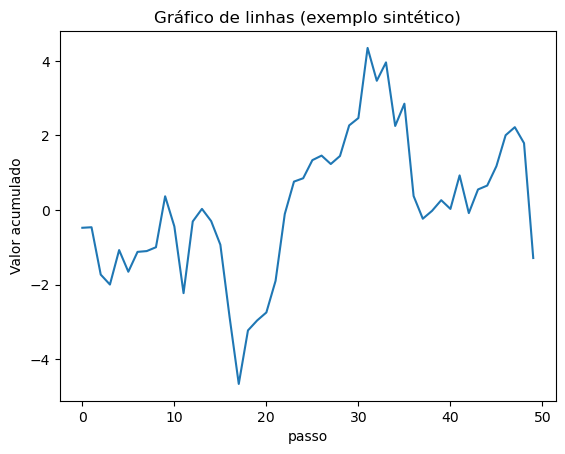

In [20]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 50)
y = np.cumsum(np.random.randn(50))  # passeio aleatório

plt.plot(x, y)
plt.title("Gráfico de linhas (exemplo sintético)")
plt.xlabel("passo")
plt.ylabel("Valor acumulado")
plt.show()

#### **2.4.2 Gráfico de barras**

**Quando usar:** comparar quantidades entre categorias.

**Exemplo:** quantos exemplos há por classe no iris.

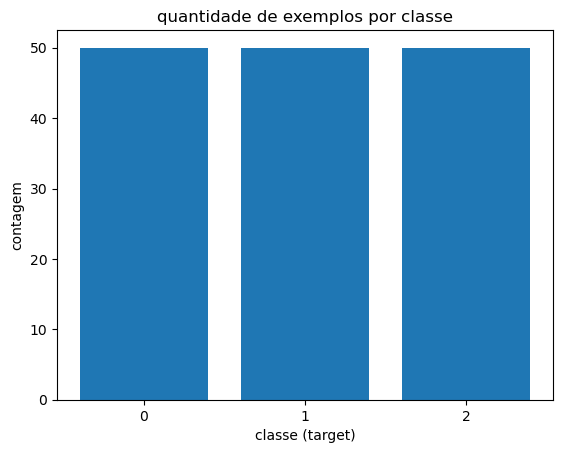

In [21]:
counts = df["target"].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title("quantidade de exemplos por classe")
plt.xlabel("classe (target)")
plt.ylabel("contagem")
plt.show()

#### **2.4.3 Gráfico de dispersão**

**Quando usar:** relação entre duas variáveis numéricas.

**Exemplo:** sepal length vs petal length, colorindo por classe.

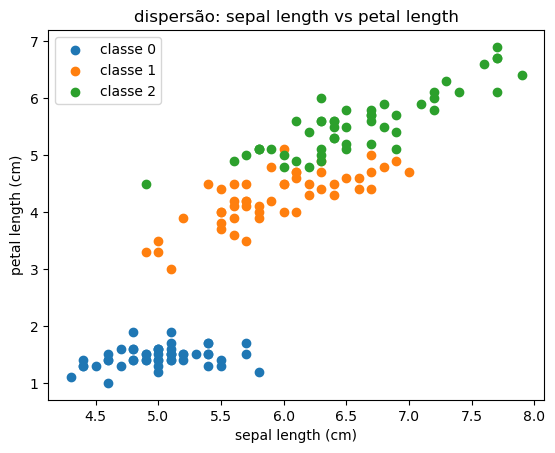

In [22]:
for cls in sorted(df["target"].unique()):
    subset = df[df["target"] == cls]
    plt.scatter(subset["sepal length (cm)"], subset["petal length (cm)"], label=f"classe {cls}")

plt.title("dispersão: sepal length vs petal length")
plt.xlabel("sepal length (cm)")
plt.ylabel("petal length (cm)")
plt.legend()
plt.show()

### **2.5 Conceituação estatística**


#### **2.5.1 Amostras**

**Definição:** amostra é um subconjunto de dados usado para estimar características da população. amostrar é útil quando a população é grande/cara de medir.

**Na prática:** comparar estatísticas da amostra com a base toda.

In [23]:
sample = df.sample(n=30, random_state=7)
print("média petal length (população):", df["petal length (cm)"].mean())
print("média petal length (amostra):  ", sample["petal length (cm)"].mean())

média petal length (população): 3.7580000000000005
média petal length (amostra):   4.089999999999999


#### **2.5.2 Classificação estatística**

**Definição:** classificar dados é identificar tipos (numérico/categórico/ordinal) e, em ML, prever rótulos (classes).

**Na prática (tipos):** ver dtypes e transformar o target em categoria.

#### 1) Dado numérico (quantitativo)

**Definição:** valores que representam **quantidades** e permitem operações matemáticas (somar, calcular média, desvio padrão, etc.).
**subtipos comuns:**

* **Discreto:** contagens (número de compras, número de filhos).
* **Contínuo:** medidas (altura, peso, preço, tempo).

**exemplo (pandas):**

In [24]:
import pandas as pd

df = pd.DataFrame({
    "idade": [18, 22, 35, 41],          # discreto (contagem de anos)
    "salario": [2500.0, 3200.5, 5400.0, 6100.0]  # contínuo (medida)
})

df.dtypes

idade        int64
salario    float64
dtype: object

In [25]:
# Operações típicas:

df[["idade", "salario"]].describe()

,idade,salario
count,4.000000,4.000000
mean,29.000000,4300.125000
std,10.801234,1722.294999
min,18.000000,2500.000000
25%,21.000000,3025.375000
50%,28.500000,4300.250000
75%,36.500000,5575.000000
max,41.000000,6100.000000


#### 2) Dado categórico (qualitativo nominal)

**Definição:** valores que representam **categorias sem ordem natural**. você pode contar frequências, comparar igualdade, agrupar, mas **não faz sentido** calcular “média” da categoria.

**Exemplos:** cor, cidade, marca, tipo de pagamento.

**exemplo (pandas):**

In [26]:
df = pd.DataFrame({
    "cor": ["azul", "preto", "azul", "vermelho"],
    "cidade": ["sp", "rj", "sp", "bh"]
})

df.dtypes

cor       object
cidade    object
dtype: object

In [27]:
# Converter para categoria (melhora memória e deixa explícito):

df["cor"] = df["cor"].astype("category")
df["cidade"] = df["cidade"].astype("category")
df.dtypes

cor       category
cidade    category
dtype: object

In [28]:
# Análises típicas:

df["cor"].value_counts()

cor
azul        2
preto       1
vermelho    1
Name: count, dtype: int64

#### 3) Dado ordinal (qualitativo ordinal)

**Definição:** valores categóricos com **ordem natural**, mas sem garantir que a “distância” entre níveis seja igual.
Ex.: “ruim < ok < bom < excelente”.
Você consegue comparar ordem, mas dizer que “excelente é 2x melhor que bom” não faz sentido.

**Exemplo (pandas):**

In [29]:
df = pd.DataFrame({
    "satisfacao": ["ruim", "ok", "bom", "excelente", "bom"]
})

ordem = ["ruim", "ok", "bom", "excelente"]
df["satisfacao"] = pd.Categorical(df["satisfacao"], categories=ordem, ordered=True)

df.dtypes

satisfacao    category
dtype: object

In [30]:
# Comparações e ordenação funcionando:

df.sort_values("satisfacao")

,satisfacao
0,ruim
1,ok
2,bom
4,bom
3,excelente


In [31]:
# Transformar em número (às vezes útil em ML, com cuidado):

df["satisfacao_code"] = df["satisfacao"].cat.codes
df

,satisfacao,satisfacao_code
0,ruim,0
1,ok,1
2,bom,2
3,excelente,3
4,bom,2


#### 2.5.3 Forma dos dados

**Definição:** forma = número de linhas (observações) e colunas (variáveis). Também se fala em “wide” (muitas colunas) vs “long” (mais linhas, dados empilhados).

**Na prática:** checar shape e transformar de wide para long com `melt`.

In [32]:
iris = load_iris(as_frame=True)
df = iris.frame  # features + coluna "target"

In [33]:
df.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [34]:
print("shape:", df.shape)
df_long = df.melt(id_vars=["target"], var_name="feature", value_name="value")
df_long.head()

shape: (150, 5)


,target,feature,value
0,0,sepal length (cm),5.1
1,0,sepal length (cm),4.9
2,0,sepal length (cm),4.7
3,0,sepal length (cm),4.6
4,0,sepal length (cm),5.0


### **2.6 Exercícios propostos (novo dataset)**

Agora é com você. Vamos usar **outro dataset** para praticar.

Dataset: **Wine** (sklearn) — dados de vinhos com várias features numéricas e classes.

In [35]:
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df_wine = wine.frame
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


#### Tarefa 1 — inspeção e `describe`
1) Use `head`, `info` e `describe`.
2) Responda: quais colunas parecem ter escalas muito diferentes?

### ✅ gabarito — tarefa 1

Abaixo estão os comandos pedidos e uma resposta objetiva sobre escalas diferentes.

In [36]:
# tarefa 1.1 — inspeção
df_wine.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [37]:
# tarefa 1.1 — info
df_wine.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [38]:
# tarefa 1.1 — describe
df_wine.describe()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


**tarefa 1.2 — resposta (escalas diferentes):**  
Algumas colunas têm escalas bem diferentes. Por exemplo, `proline` costuma ter valores na casa de **centenas/milhares**, enquanto `hue` e `nonflavanoid_phenols` ficam perto de **0.x a 1.x**. `magnesium` e `alcalinity_of_ash` também ficam em escalas bem diferentes de `hue`.

Uma forma “objetiva” de checar é olhar `min`, `max` e o `range` das features:


In [39]:
import numpy as np
import pandas as pd

scales = df_wine.drop(columns=["target"]).agg(["min", "max"]).T
scales["range"] = scales["max"] - scales["min"]
scales.sort_values("range", ascending=False).head(10)


,min,max,range
proline,278.00,1680.00,1402.00
magnesium,70.00,162.00,92.00
alcalinity_of_ash,10.60,30.00,19.40
color_intensity,1.28,13.00,11.72
malic_acid,0.74,5.80,5.06
flavanoids,0.34,5.08,4.74
alcohol,11.03,14.83,3.80
proanthocyanins,0.41,3.58,3.17
total_phenols,0.98,3.88,2.90
od280/od315_of_diluted_wines,1.27,4.00,2.73


#### Tarefa 2 — navegação e filtros
1) Crie um filtro para ver apenas linhas onde `alcohol` é maior que a mediana.
2) Ordene pela coluna `color_intensity` (desc).
3) Mostre as 5 primeiras linhas.

### ✅ gabarito — tarefa 2

In [40]:
# tarefa 2.1 — filtro alcohol > mediana
mediana_alcohol = df_wine["alcohol"].median()
df_filtro = df_wine[df_wine["alcohol"] > mediana_alcohol]

mediana_alcohol, df_filtro.shape


(13.05, (85, 14))

In [41]:
# tarefa 2.2 e 2.3 — ordenar e mostrar top 5
df_filtro_ordenado = df_filtro.sort_values("color_intensity", ascending=False)
df_filtro_ordenado.head(5)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
158,14.34,1.68,2.70,25.0,98.0,2.80,1.31,0.53,2.70,13.00,0.57,1.96,660.0,2
159,13.48,1.67,2.64,22.5,89.0,2.60,1.10,0.52,2.29,11.75,0.57,1.78,620.0,2
166,13.45,3.70,2.60,23.0,111.0,1.70,0.92,0.43,1.46,10.68,0.85,1.56,695.0,2
153,13.23,3.30,2.28,18.5,98.0,1.80,0.83,0.61,1.87,10.52,0.56,1.51,675.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2


#### Tarefa 3 — criação de feature
1) Crie uma nova coluna `phenols_ratio = total_phenols / flavanoids`.
2) Lide com divisões por zero (se aparecer).
3) Mostre `describe` dessa nova coluna.

### ✅ gabarito — tarefa 3

In [42]:
# tarefa 3 — criação de feature (com proteção para divisão por zero)
df_wine2 = df_wine.copy()

den = df_wine2["flavanoids"].replace(0, np.nan)  # evita divisão por zero
df_wine2["phenols_ratio"] = df_wine2["total_phenols"] / den

df_wine2[["total_phenols", "flavanoids", "phenols_ratio"]].head()


,total_phenols,flavanoids,phenols_ratio
0,2.80,3.06,0.915033
1,2.65,2.76,0.960145
2,2.80,3.24,0.864198
3,3.85,3.49,1.103152
4,2.80,2.69,1.040892


In [43]:
# tarefa 3.3 — describe da nova coluna
df_wine2["phenols_ratio"].describe()


count    178.000000
mean       1.412667
std        0.721205
min        0.625984
25%        0.946117
50%        1.066422
75%        1.606981
max        3.866667
Name: phenols_ratio, dtype: float64

Se aparecer `NaN`, é porque havia `flavanoids = 0` em alguma linha (divisão por zero).

#### Tarefa 4 — gráficos
1) Faça um gráfico de barras com a contagem por classe (`target`).
2) Faça um scatter `alcohol` vs `color_intensity` colorido por classe.
3) Invente um gráfico de linhas (pode ser um índice ordenado por `alcohol`). explique o que esse gráfico está mostrando e suas limitações.

### ✅ gabarito — tarefa 4

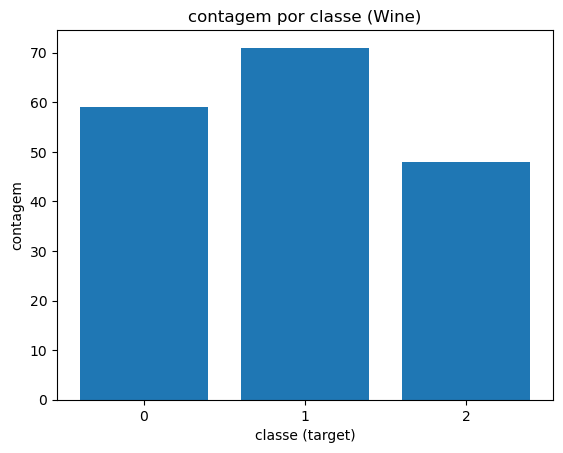

In [44]:
import matplotlib.pyplot as plt

# tarefa 4.1 — barras: contagem por classe
counts = df_wine["target"].value_counts().sort_index()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("classe (target)")
plt.ylabel("contagem")
plt.title("contagem por classe (Wine)")
plt.show()


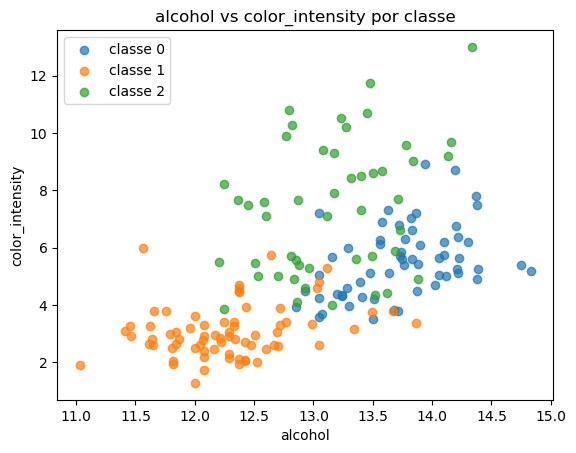

In [45]:
# tarefa 4.2 — scatter alcohol vs color_intensity por classe
plt.figure()
for cls in sorted(df_wine["target"].unique()):
    sub = df_wine[df_wine["target"] == cls]
    plt.scatter(sub["alcohol"], sub["color_intensity"], label=f"classe {cls}", alpha=0.7)

plt.xlabel("alcohol")
plt.ylabel("color_intensity")
plt.title("alcohol vs color_intensity por classe")
plt.legend()
plt.show()


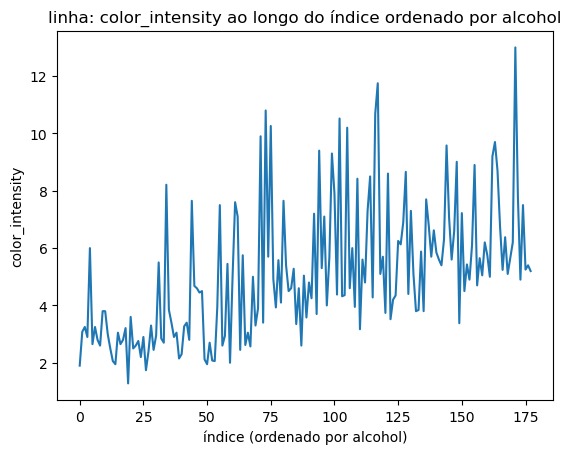

In [46]:
# tarefa 4.3 — gráfico de linhas (exemplo): ordenar por alcohol e plotar color_intensity ao longo do índice ordenado
df_ord = df_wine.sort_values("alcohol").reset_index(drop=True)

plt.figure()
plt.plot(df_ord.index, df_ord["color_intensity"])
plt.xlabel("índice (ordenado por alcohol)")
plt.ylabel("color_intensity")
plt.title("linha: color_intensity ao longo do índice ordenado por alcohol")
plt.show()


**explicação (tarefa 4.3):**  
Esse gráfico mostra como a variável `color_intensity` varia quando percorremos as amostras em ordem crescente de `alcohol`.  
**limitações:** não é uma série temporal; o eixo x não representa tempo nem uma sequência “natural” do fenômeno. A forma da curva pode mudar se você ordenar por outra coluna.


#### Tarefa 5 — Responda
- (a) Quais **3 features** mais diferenciam as classes olhando **média por classe**?
- (b) Existe alguma feature com **muita sobreposição** entre classes no scatter? qual seria um efeito disso em um classificador?
- (c) Escolha uma transformação (ex.: log, normalização) em uma coluna com escala muito alta/baixa. o que muda em `describe`?

### ✅ gabarito — tarefa 5

In [47]:
# tarefa 5a — 3 features que mais diferenciam olhando média por classe
features = [c for c in df_wine.columns if c != "target"]
media_por_classe = df_wine.groupby("target")[features].mean()

# diferença simples entre médias (max - min)
dif = (media_por_classe.max() - media_por_classe.min()).sort_values(ascending=False)
dif.head(10)


proline                         596.204822
magnesium                        11.789687
alcalinity_of_ash                 4.379379
color_intensity                   4.309630
flavanoids                        2.200915
od280/od315_of_diluted_wines      1.474255
alcohol                           1.466013
malic_acid                        1.401074
total_phenols                     1.161419
proanthocyanins                   0.745780
dtype: float64

**resposta (5a):** pegue as **3 primeiras** do ranking acima (maior diferença de médias entre classes).  
Tipicamente, aparecem no topo: `proline`, `flavanoids`, `color_intensity` (ou `od280/od315_of_diluted_wines`).


In [48]:
# tarefa 5b — checar sobreposição no scatter (resumo numérico)
df_wine.groupby("target")[["alcohol", "color_intensity"]].describe()


alcohol                                                             \
         count       mean       std    min     25%     50%     75%    max   
target                                                                      
0         59.0  13.744746  0.462125  12.85  13.400  13.750  14.100  14.83   
1         71.0  12.278732  0.537964  11.03  11.915  12.290  12.515  13.86   
2         48.0  13.153750  0.530241  12.20  12.805  13.165  13.505  14.34   

       color_intensity                                                       
                 count      mean       std   min     25%   50%    75%   max  
target                                                                       
0                 59.0  5.528305  1.238573  3.52  4.5500  5.40  6.225   8.9  
1                 71.0  3.086620  0.924929  1.28  2.5350  2.90  3.400   6.0  
2                 48.0  7.396250  2.310942  3.85  5.4375  7.55  9.225  13.0

**resposta (5b):** há alguma sobreposição entre classes no scatter (principalmente em `alcohol`).  
**efeito em um classificador:** mais sobreposição tende a aumentar erros (confusão entre classes), especialmente se o modelo usar poucas features ou se elas não separarem bem as classes.


In [49]:
# tarefa 5c — transformação em coluna de escala alta (ex.: log1p em proline)
df_transf = df_wine.copy()
df_transf["proline_log"] = np.log1p(df_transf["proline"])

df_wine["proline"].describe(), df_transf["proline_log"].describe()


(count     178.000000
 mean      746.893258
 std       314.907474
 min       278.000000
 25%       500.500000
 50%       673.500000
 75%       985.000000
 max      1680.000000
 Name: proline, dtype: float64,
 count    178.000000
 mean       6.531887
 std        0.414475
 min        5.631212
 25%        6.217602
 50%        6.513969
 75%        6.893656
 max        7.427144
 Name: proline_log, dtype: float64)

**resposta (5c):** o log “comprime” valores grandes, reduz a assimetria e diminui a diferença entre máximos e mínimos (a escala fica mais “controlada”).  
Isso pode ajudar alguns modelos e também facilita visualização/normalização.


#### (opcional) Desafio
Faça um baseline de classificação como fizemos no iris (classe mais frequente). depois treine uma `LogisticRegression` e compare as acurácias.

### ✅ gabarito — desafio (opcional)

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df_wine.drop(columns=["target"])
y = df_wine["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# baseline: prever sempre a classe mais frequente no treino
classe_mais_freq = y_train.value_counts().idxmax()
pred_base = np.full(shape=len(y_test), fill_value=classe_mais_freq)
acc_baseline = accuracy_score(y_test, pred_base)

classe_mais_freq, acc_baseline


(np.int64(1), 0.4)

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)

print("accuracy:", accuracy_score(y_test, pred))
print("confusion matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

accuracy: 1.0
confusion matrix:
 [[15  0  0]
 [ 0 18  0]
 [ 0  0 12]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



**interpretação:** compare `acc_baseline` vs `acc_lr`.  
O baseline costuma ficar bem abaixo do modelo (porque ignora as features). A Logistic Regression tende a performar muito bem nesse dataset.


---

© 2026 Jones Egydio. Todos os direitos reservados.  

Conecte-se comigo no [LinkedIn](https://www.linkedin.com/in/jones-egydio-msc-3300359/).
